# 1. Carga y Procesamiento de Datos

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
from sklearn.exceptions import ConvergenceWarning
from google.colab import files

data = pd.read_excel("TA_2023-2026.xlsx")
df = pd.read_csv("Base_Actualizada.csv")

# Limpiar Nulos

df["sector_economico_1"] = df["sector_economico_1"].fillna(0)
df["sector_economico_2"] = df["sector_economico_2"].fillna(0)

# Convertimos a Entero
df["sector_economico_1"] = df["sector_economico_1"].astype(int)
df["sector_economico_2"] = df["sector_economico_2"].astype(int)

# Crear columna concatenada

df["Sector_Concat"] = ("S" + df["sector_economico_1"].astype(str) +"G" + df["sector_economico_2"].astype(str))
#Eliminar S1G14
df

,Año,sector_economico_1,sector_economico_2,ta,asegurados,Sector_Concat
0,31/03/2010,0,1,40878,NaN,S0G1
1,30/04/2010,0,1,41721,NaN,S0G1
2,31/05/2010,0,1,38311,NaN,S0G1
3,30/06/2010,0,1,37119,NaN,S0G1
4,31/07/2010,0,1,37401,NaN,S0G1
...,...,...,...,...,...,...
11837,30/09/2025,9,99,162,162.0,S9G99
11838,31/10/2025,9,99,162,162.0,S9G99
11839,30/11/2025,9,99,158,158.0,S9G99
11840,31/12/2025,9,99,157,157.0,S9G99


In [2]:
Modelos = pd.read_excel("Coeficientes.xlsx")
data["descripción sector_economico_2"].nunique()
data["descripción sector_economico_2"].unique()

array(['Agricultura', 'Ganadería', 'Silvicultura', 'Pesca', 'Caza',
       'Extracción y Beneficio de Carbón Mineral, Grafito y Minerales no Metálicos; excepto Sal',
       'Exploración y Extracción de Petróleo Crudo y Gas Natural',
       'Extracción y Beneficio de Minerales Metálicos',
       'Explotación de Sal', 'Elaboración de Alimentos',
       'Elaboración de Bebidas',
       'Beneficio y/o Fabricación de Productos de Tabaco',
       'Industria Textil',
       'Confección de Prendas de Vestir y otros Artículos a base de Textiles y Materiales Diversos; excepto Calzado',
       'Fabricación de Calzado e Industria del Cuero',
       'Industria y Productos de Madera y Corcho; excepto Muebles',
       'Fabricación y/o Reparación de Muebles de Madera y sus Partes; excepto los de Metal y de Plástico Moldeado',
       'Industria del Papel',
       'Industrias Editorial, de Impresión y Conexas',
       'Industria Química',
       'Refinación del Petróleo y derivados del Carbón Mineral',


In [5]:
Intensidad = pd.read_csv("Intensidad_Laboral.csv")
Intensidad['I']

,I
0,1.641997
1,0.460710
2,0.440464
3,6.098039
4,6.098039
...,...
56,0.951698
57,1.061654
58,0.142595
59,4.728019


# Eliminar S1G14

In [6]:
#Solo lo útil
df = df[["Año", "Sector_Concat", "ta"]].copy()
df = df.dropna(subset=["Año", "Sector_Concat", "ta"])
df = df[df["ta"] > 0]

df.head(2)

,Año,Sector_Concat,ta
0,31/03/2010,S0G1,40878
1,30/04/2010,S0G1,41721


In [7]:
df.Sector_Concat.describe()

,Sector_Concat
count,11715
unique,62
top,S0G1
freq,191


Acomodo de dataframe para poder iniciar el modelo

In [8]:
# Pivot: filas = fecha, columnas = Sector_Concat, valores = ta
wide = df.pivot_table(index="Año", columns="Sector_Concat", values="ta", aggfunc="mean")

# Ordenar por fecha
wide.index = pd.to_datetime(wide.index)
wide = wide.sort_index()

print("NAs totales:", wide.isna().sum().sum())
wide.head(2)

NAs totales: 127


/tmp/ipykernel_52145/1155302868.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  wide.index = pd.to_datetime(wide.index)


Sector_Concat,S0G1,S0G2,S0G3,S0G4,S0G5,S1G11,S1G12,S1G13,S1G14,S2G20,...,S8G85,S8G86,S8G87,S8G88,S8G89,S9G91,S9G92,S9G93,S9G94,S9G99
Año,,,,,,,,,,,,,,,,,,,,,
2010-03-31,40878.0,15525.0,448.0,314.0,6.0,1383.0,5.0,756.0,9.0,61750.0,...,3926.0,21884.0,33623.0,11836.0,35783.0,39956.0,17662.0,5346.0,162505.0,117.0
2010-04-30,41721.0,15533.0,517.0,301.0,6.0,1377.0,5.0,796.0,9.0,62052.0,...,3820.0,21575.0,33300.0,11926.0,35759.0,39307.0,18138.0,5490.0,162892.0,118.0


# 2. Modelo STL

In [9]:
from statsmodels.tsa.seasonal import STL

def stl_adjust_one_series(y: pd.Series, period: int = 12, robust: bool = True) -> pd.Series:
    """
    Devuelve la serie ajustada estacionalmente: y - seasonal
    - STL NO acepta NaNs, así que:
      * rellena temporalmente (interpolate time + ffill/bfill) solo para estimar seasonal
      * regresa NaNs a las posiciones originalmente faltantes
    """
    y = y.copy()
    nan_mask = y.isna()

    # Si todo es NaN o muy corta, regresamos tal cual
    y_nonan = y.dropna()
    if len(y_nonan) < max(2 * period, 24):  # regla práctica mínima
        return y

    # Relleno temporal SOLO para STL
    y_fill = y.interpolate(method="time", limit_direction="both")
    y_fill = y_fill.ffill().bfill()

    # STL
    stl = STL(y_fill, period=period, robust=robust)
    res = stl.fit()

    y_sa = y_fill - res.seasonal  # y ajustada estacionalmente
    y_sa[nan_mask] = np.nan       # restaurar NaNs originales

    return y_sa

# 2.1 Aplicar STL a todas las columnas
period = 12

# Convertir el índice a DatetimeIndex
wide.index = pd.to_datetime(wide.index)

wide_sa = pd.DataFrame(index=wide.index)

for col in wide.columns:
    wide_sa[col] = stl_adjust_one_series(wide[col], period=period, robust=True)

print("wide_sa shape:", wide_sa.shape)
print("NaNs totales (wide_sa):", wide_sa.isna().sum().sum())

wide_sa shape: (191, 62)
NaNs totales (wide_sa): 127


Apliqué Modelo STL con los datos crudos, no con diferencias logaritmicas (así lo indicaba el documento) posible mejora

In [10]:
wide_sa.head(2)

,S0G1,S0G2,S0G3,S0G4,S0G5,S1G11,S1G12,S1G13,S1G14,S2G20,...,S8G85,S8G86,S8G87,S8G88,S8G89,S9G91,S9G92,S9G93,S9G94,S9G99
Año,,,,,,,,,,,,,,,,,,,,,
2010-03-31,39287.870459,15606.470236,433.656722,245.456256,6.088095,1325.155570,5.420309,671.449974,8.999137,60953.627111,...,3860.289168,21144.735313,33514.252524,11765.909276,35272.319120,38596.772225,18215.450415,5431.078180,162487.374658,120.249678
2010-04-30,39762.609332,15704.593183,437.689469,225.033288,6.017538,1325.664929,5.253401,699.786238,8.997761,61087.150595,...,3885.833038,21008.010107,33207.934848,11736.203864,35333.846089,38778.855013,18293.338851,5459.595101,163159.020466,120.733191


Aplicación de logaritmos

In [11]:
# Revisar si hay valores <= 0
print("Valores <= 0:", (wide_sa <= 0).sum().sum())

# Reemplazar valores <= 0 por NaN
wide_sa_clean = wide_sa.copy()
wide_sa_clean[wide_sa_clean <= 0] = np.nan

log_wide = np.log(wide_sa_clean)

g = log_wide.diff()

# 3.4 Eliminar primera fila (queda NaN por diff)

g = g.iloc[1:]

print("Dimensión matriz g:", g.shape)
print("NaNs totales en g:", g.isna().sum().sum())
g.head()


Valores <= 0: 5
Dimensión matriz g: (190, 62)
NaNs totales en g: 136


,S0G1,S0G2,S0G3,S0G4,S0G5,S1G11,S1G12,S1G13,S1G14,S2G20,...,S8G85,S8G86,S8G87,S8G88,S8G89,S9G91,S9G92,S9G93,S9G94,S9G99
Año,,,,,,,,,,,,,,,,,,,,,
2010-04-30,0.012011,0.006268,0.009256,-0.086870,-0.011657,0.000384,-0.031277,0.041335,-0.000153,0.002188,...,0.006595,-0.006487,-0.009182,-0.002528,0.001743,0.004706,0.004267,0.005237,0.004125,0.004013
2010-05-31,0.007595,0.002142,-0.023810,0.509309,-0.044415,0.008586,-0.016135,0.075185,0.000187,0.007832,...,-0.010282,0.014278,0.011266,0.005883,0.003933,-0.000945,0.005305,0.011411,0.001750,0.008493
2010-06-30,-0.014370,0.004281,0.001005,0.002332,0.032809,0.002947,-0.016887,0.043885,0.105225,-0.001295,...,0.020467,0.003938,-0.005250,-0.004009,0.003468,0.003553,0.000452,0.001653,0.003872,0.001742
2010-07-31,0.003980,0.003086,-0.024621,-0.017925,0.008207,0.012640,-0.001076,0.014651,0.095462,0.003128,...,0.013169,-0.000794,0.018304,0.009921,0.005078,0.002529,-0.004523,0.004450,0.003588,0.005316
2010-08-31,0.017257,0.009646,-0.001582,-0.038968,-0.017255,0.002386,-0.012114,0.089789,NaN,0.001788,...,-0.024642,0.015099,-0.004659,0.002781,0.014746,-0.003376,-0.003336,0.000097,0.003675,0.000777


In [12]:
g_filled = g.copy()
g_filled = g_filled.fillna(0)

print("Dimensión g_filled:", g_filled.shape)
print("NaNs restantes:", g_filled.isna().sum().sum())

Dimensión g_filled: (190, 62)
NaNs restantes: 0


#3. Matriz B

In [13]:
sectors = g_filled.columns
n = len(sectors)

# Matrices de coeficientes
B_min = pd.DataFrame(np.zeros((n, n)), index=sectors, columns=sectors)
B_1se = pd.DataFrame(np.zeros((n, n)), index=sectors, columns=sectors)

# Igual que en R: aquí eliges cuál usar finalmente
# opciones: "lambda_min" o "lambda_1se"
s_used = "lambda_min"

# Matriz final que vas a usar después
B = pd.DataFrame(np.zeros((n, n)), index=sectors, columns=sectors)

# Tabla de resultados estilo R
results = pd.DataFrame({
    "target": sectors,
    "r2": np.nan,
    "rmse": np.nan,
    "mae": np.nan,
    "mape": np.nan,
    "n_betas_no_cero": np.nan,
    "n_betas_negativas": np.nan,
    "lambda_min": np.nan,
    "lambda_1se": np.nan
})

warnings.filterwarnings("ignore", category=ConvergenceWarning)

for i, target in enumerate(sectors):

    # Variable dependiente
    y = g_filled[target].values

    # Variables explicativas
    X_df = g_filled.drop(columns=[target])
    X = X_df.values
    other_sectors = X_df.columns

    # Estandarización de X (igual que tu versión actual)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # LASSO con validación cruzada
    lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso_cv.fit(X_scaled, y)

    # -------- lambda_min --------
    lambda_min = lasso_cv.alpha_

    # -------- lambda_1se --------
    # sklearn no lo da directo como glmnet, así que lo construimos manualmente
    mse_mean = np.mean(lasso_cv.mse_path_, axis=1)
    mse_std  = np.std(lasso_cv.mse_path_, axis=1, ddof=1)

    idx_min = np.argmin(mse_mean)
    mse_min = mse_mean[idx_min]
    se_min  = mse_std[idx_min]

    threshold = mse_min + se_min

    # En sklearn alphas_ suele venir de mayor a menor
    # Tomamos el alpha más grande cuyo error esté dentro de 1 se del mínimo
    valid_idx = np.where(mse_mean <= threshold)[0]
    idx_1se = valid_idx[0]
    lambda_1se = lasso_cv.alphas_[idx_1se]

    # Ajustar modelos explícitos con ambos lambdas
    model_min = Lasso(alpha=lambda_min, max_iter=10000)
    model_min.fit(X_scaled, y)

    model_1se = Lasso(alpha=lambda_1se, max_iter=10000)
    model_1se.fit(X_scaled, y)

    # Guardar ambas matrices
    B_min.loc[target, other_sectors] = model_min.coef_
    B_1se.loc[target, other_sectors] = model_1se.coef_

    # Elegir cuál usar igual que en R
    if s_used == "lambda_min":
        model_used = model_min
        betas = model_min.coef_
    elif s_used == "lambda_1se":
        model_used = model_1se
        betas = model_1se.coef_
    else:
        raise ValueError("s_used debe ser 'lambda_min' o 'lambda_1se'")

    # Guardar en la matriz final B
    B.loc[target, other_sectors] = betas

    # Predicciones con el lambda elegido
    y_hat = model_used.predict(X_scaled)

    # Métricas
    r2 = r2_score(y, y_hat)
    rmse = np.sqrt(mean_squared_error(y, y_hat))
    mae = mean_absolute_error(y, y_hat)

    # MAPE como en R: si hay ceros, mejor dejarlo como NaN
    if np.any(y == 0):
        mape = np.nan
    else:
        mape = np.mean(np.abs((y - y_hat) / y)) * 100

    # Guardar resultados
    results.loc[i, "r2"] = r2
    results.loc[i, "rmse"] = rmse
    results.loc[i, "mae"] = mae
    results.loc[i, "mape"] = mape
    results.loc[i, "n_betas_no_cero"] = np.sum(betas != 0)
    results.loc[i, "n_betas_negativas"] = np.sum(betas < 0)
    results.loc[i, "lambda_min"] = lambda_min
    results.loc[i, "lambda_1se"] = lambda_1se

print(f"Matriz B estimada usando {s_used}:")
B

Matriz B estimada usando lambda_min:


,S0G1,S0G2,S0G3,S0G4,S0G5,S1G11,S1G12,S1G13,S1G14,S2G20,...,S8G85,S8G86,S8G87,S8G88,S8G89,S9G91,S9G92,S9G93,S9G94,S9G99
S0G1,0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.000000,0.0,0.0,...,-0.0,-0.0,0.0,0.000000,-0.0,0.0,-0.0,0.0,-0.0,0.0
S0G2,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.000000,-0.0,-0.0,...,-0.0,0.0,-0.0,-0.000000,-0.0,0.0,-0.0,-0.0,0.0,-0.0
S0G3,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.000000,0.0,-0.0,...,0.0,0.0,0.0,0.000000,-0.0,0.0,-0.0,0.0,0.0,0.0
S0G4,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.000000,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.003858,0.0,-0.0,-0.0,-0.0,-0.0,-0.0
S0G5,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.000000,-0.0,-0.0,...,0.0,0.0,0.0,0.000000,-0.0,0.0,-0.0,-0.0,-0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S9G91,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,-0.0,0.0,0.0,-0.0
S9G92,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000187,-0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,-0.0,0.0,0.0,-0.0,0.0
S9G93,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,-0.0,0.0,0.0,0.0,-0.0,-0.0
S9G94,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.000000,0.0,-0.0,...,-0.0,-0.0,-0.0,-0.000000,-0.0,0.0,-0.0,-0.0,0.0,-0.0


In [ ]:
nombre_archivo = "B.xlsx"

B.to_excel(nombre_archivo, index=True)

#files.download(nombre_archivo)

In [21]:
B = pd.read_csv('Betas_no_estandarizados_py.csv', index_col=0)
B

,s0_g1,s0_g2,s0_g3,s0_g4,s0_g5,s1_g11,s1_g12,s1_g13,s2_g20,s2_g21,...,s8_g85,s8_g86,s8_g87,s8_g88,s8_g89,s9_g91,s9_g92,s9_g93,s9_g94,s9_g99
s0_g1,0.000000,0.0,-0.0,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,0.0,...,-0.0,0.000000,-0.000,0.000000,0.000000,0.000000,-0.0,0.000000,0.000000,0.000000
s0_g2,0.000000,0.0,0.0,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.229322,0.0,...,0.0,0.000000,0.000,-0.000000,-0.000000,0.000000,0.0,-0.000000,0.000000,-0.000000
s0_g3,-0.000000,0.0,0.0,-0.000000,0.000000,0.162758,0.000000,0.000000,0.000000,-0.0,...,0.0,-0.000000,0.000,-0.000000,-0.000000,-0.000000,0.0,0.071495,0.000000,0.000000
s0_g4,-0.057761,0.0,-0.0,0.000000,0.000000,-0.000000,-0.099216,0.000000,0.684633,-0.0,...,-0.0,-0.000000,0.000,-1.675435,0.388169,-0.000000,-0.0,-0.000000,-0.000000,-0.000000
s0_g5,-0.000000,0.0,0.0,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,0.0,...,0.0,0.000000,0.000,0.000000,-0.000000,0.000000,-0.0,-0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s9_g91,-0.000000,-0.0,-0.0,-0.001601,0.000725,0.000000,0.000000,-0.008242,0.000000,-0.0,...,0.0,0.018748,0.061,0.040208,-0.000000,0.000000,-0.0,0.000000,0.000000,-0.030778
s9_g92,-0.000000,-0.0,0.0,0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,0.0,...,0.0,0.000000,0.000,-0.000000,0.000000,0.000000,0.0,-0.000000,-0.000000,-0.000000
s9_g93,0.000000,-0.0,0.0,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,-0.0,...,0.0,0.000000,0.000,-0.000000,-0.000000,0.000000,-0.0,0.000000,-0.000000,-0.000000
s9_g94,0.000000,0.0,-0.0,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.0,...,0.0,-0.000000,-0.000,0.000000,-0.000000,0.000000,-0.0,-0.000000,0.000000,-0.000000


In [22]:
total = B.size
non_zero = (B != 0).sum().sum()

print("Total coeficientes:", total)
print("No cero:", non_zero)
print("Densidad:", non_zero / total)

Total coeficientes: 3721
No cero: 315
Densidad: 0.08465466272507391


In [16]:
print("Resumen de lambdas")
print("Lambda_min promedio:", results["lambda_min"].mean())
print("Lambda_min mínimo:", results["lambda_min"].min())
print("Lambda_min máximo:", results["lambda_min"].max())

print("\nLambda_1se promedio:", results["lambda_1se"].mean())
print("Lambda_1se mínimo:", results["lambda_1se"].min())
print("Lambda_1se máximo:", results["lambda_1se"].max())

Resumen de lambdas
Lambda_min promedio: 0.011620130156568187
Lambda_min mínimo: 0.00034875741987513384
Lambda_min máximo: 0.31985093842284573

Lambda_1se promedio: 0.012799651289571709
Lambda_1se mínimo: 0.0014278527024587223
Lambda_1se máximo: 0.31985093842284573


In [17]:
print("Top 10 sectores por mejor ajuste (R²):")
results.sort_values("r2", ascending=False).head(10)

Top 10 sectores por mejor ajuste (R²):


,target,r2,rmse,mae,mape,n_betas_no_cero,n_betas_negativas,lambda_min,lambda_1se
55,S8G88,0.460222,0.014341,0.009606,207.398745,19.0,6.0,0.001206,0.008510
48,S8G81,0.444842,0.015291,0.009838,327.488477,21.0,7.0,0.001257,0.009510
24,S3G35,0.411795,0.005026,0.004011,125.814269,29.0,6.0,0.000349,0.002295
51,S8G84,0.389687,0.010318,0.007633,167.332843,16.0,9.0,0.001147,0.006120
10,S2G21,0.367720,0.007595,0.005140,388.499774,17.0,7.0,0.000794,0.003205
29,S4G41,0.365767,0.012792,0.008997,182.408044,14.0,3.0,0.001581,0.005951
16,S2G27,0.290334,0.009734,0.006778,194.941677,9.0,1.0,0.001149,0.004639
21,S3G32,0.284382,0.008522,0.005836,214.865501,22.0,10.0,0.000795,0.002792
30,S4G42,0.265244,0.011755,0.008753,249.220875,15.0,3.0,0.001281,0.003912
54,S8G87,0.215817,0.011829,0.007287,207.264387,4.0,0.0,0.004205,0.006853


In [18]:
results

,target,r2,rmse,mae,mape,n_betas_no_cero,n_betas_negativas,lambda_min,lambda_1se
0,S0G1,0.000000,0.020985,0.015162,210.253397,1.0,0.0,0.004220,0.004220
1,S0G2,0.000000,0.019056,0.009663,154.171736,0.0,0.0,0.004083,0.004083
2,S0G3,0.000000,0.049720,0.029680,128.039425,0.0,0.0,0.011231,0.011231
3,S0G4,0.025951,0.174411,0.082097,102.082157,2.0,2.0,0.057708,0.061879
4,S0G5,0.000000,0.067613,0.041962,247.213323,1.0,0.0,0.011744,0.011744
...,...,...,...,...,...,...,...,...,...
57,S9G91,0.000000,0.007096,0.004079,235.386867,0.0,0.0,0.001989,0.001989
58,S9G92,0.008899,0.010566,0.006178,175.852744,1.0,1.0,0.002587,0.002774
59,S9G93,0.000000,0.019700,0.009426,191.644888,0.0,0.0,0.004450,0.004450
60,S9G94,0.000000,0.006032,0.003742,146.825428,0.0,0.0,0.001428,0.001428


In [23]:
# Grado de salida (cuántos sectores impacta cada uno)
out_degree = (B != 0).sum(axis=1)

# Grado de entrada (cuántos impactan a cada sector)
in_degree = (B != 0).sum(axis=0)

print("Top 10 sectores más influyentes:")
out_degree.sort_values(ascending=False).head()

Top 10 sectores más influyentes:


,0
s3_g35,26
s0_g4,24
s6_g64,20
s9_g99,19
s9_g91,19


In [24]:
print("\nTop 10 sectores más dependientes:")
in_degree.sort_values(ascending=False).head()


Top 10 sectores más dependientes:


,0
s3_g35,11
s8_g87,11
s2_g27,10
s7_g75,10
s8_g81,10


In [25]:
print("Coeficientes negativos:", (B < 0).sum().sum())

Coeficientes negativos: 104


Cambiar negativos a 0

In [26]:
A = B.copy()

# Eliminar coeficientes negativos
A[A < 0] = 0

print("Negativos en A:", (A < 0).sum().sum())
print("No cero en A:", (A != 0).sum().sum())

Negativos en A: 0
No cero en A: 211


In [27]:
np.fill_diagonal(A.values, 0)

In [28]:
print("Diagonal:", np.diag(A).sum())
print("Negativos:", (A < 0).sum().sum())

Diagonal: 0.0
Negativos: 0


In [29]:
A

,s0_g1,s0_g2,s0_g3,s0_g4,s0_g5,s1_g11,s1_g12,s1_g13,s2_g20,s2_g21,...,s8_g85,s8_g86,s8_g87,s8_g88,s8_g89,s9_g91,s9_g92,s9_g93,s9_g94,s9_g99
s0_g1,0.0,0.0,-0.0,-0.0,-0.000000,0.000000,-0.0,-0.0,0.000000,0.0,...,-0.0,0.000000,-0.000,0.000000,0.000000,0.0,-0.0,0.000000,0.0,0.0
s0_g2,0.0,0.0,0.0,-0.0,0.000000,-0.000000,0.0,-0.0,0.000000,0.0,...,0.0,0.000000,0.000,-0.000000,-0.000000,0.0,0.0,-0.000000,0.0,-0.0
s0_g3,-0.0,0.0,0.0,-0.0,0.000000,0.162758,0.0,0.0,0.000000,-0.0,...,0.0,-0.000000,0.000,-0.000000,-0.000000,-0.0,0.0,0.071495,0.0,0.0
s0_g4,0.0,0.0,-0.0,0.0,0.000000,-0.000000,0.0,0.0,0.684633,-0.0,...,-0.0,-0.000000,0.000,0.000000,0.388169,-0.0,-0.0,-0.000000,-0.0,-0.0
s0_g5,-0.0,0.0,0.0,0.0,0.000000,0.000000,-0.0,-0.0,0.000000,0.0,...,0.0,0.000000,0.000,0.000000,-0.000000,0.0,-0.0,-0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s9_g91,-0.0,-0.0,-0.0,0.0,0.000725,0.000000,0.0,0.0,0.000000,-0.0,...,0.0,0.018748,0.061,0.040208,-0.000000,0.0,-0.0,0.000000,0.0,0.0
s9_g92,-0.0,-0.0,0.0,0.0,-0.000000,-0.000000,0.0,-0.0,0.000000,0.0,...,0.0,0.000000,0.000,-0.000000,0.000000,0.0,0.0,-0.000000,-0.0,-0.0
s9_g93,0.0,-0.0,0.0,-0.0,-0.000000,-0.000000,0.0,0.0,0.000000,-0.0,...,0.0,0.000000,0.000,-0.000000,-0.000000,0.0,-0.0,0.000000,-0.0,-0.0
s9_g94,0.0,0.0,-0.0,-0.0,0.000000,-0.000000,0.0,-0.0,-0.000000,0.0,...,0.0,-0.000000,-0.000,0.000000,-0.000000,0.0,-0.0,-0.000000,0.0,-0.0


Condición de estabilidad

In [30]:
# 1) Calcular radio espectral
eigvals = np.linalg.eigvals(A.values)
rho = np.max(np.abs(eigvals))

print("Radio espectral rho(A):", rho)

# 2) Si no cumple estabilidad, reescalar
if rho >= 1:
    factor = 0.99 / rho   # deja rho(A) ~ 0.99 (margen de estabilidad)
    A_stable = A * factor
    print(f"Reescalando A por factor: {factor:.6f}")

    # Recalcular rho para confirmar
    eigvals2 = np.linalg.eigvals(A_stable.values)
    rho2 = np.max(np.abs(eigvals2))
    print("Nuevo radio espectral rho(A_stable):", rho2)
else:
    A_stable = A.copy()
    print("A ya cumple estabilidad, no se reescala.")

Radio espectral rho(A): 0.49315664960955763
A ya cumple estabilidad, no se reescala.



Leontief



In [ ]:
A_stable.to_excel("matrizA.xlsx")

In [31]:
# Identidad
I = np.eye(A_stable.shape[0])

# Matriz (I - A)
M = I - A_stable.values

# Inversa de Leontief
L = np.linalg.inv(M)

# Guardarlo como DataFrame para mantener nombres
L_df = pd.DataFrame(L, index=A_stable.index, columns=A_stable.columns)

print("Leontief listo. Shape:", L_df.shape)
print(L_df.iloc[:5, :5])

Leontief listo. Shape: (61, 61)
              s0_g1         s0_g2         s0_g3         s0_g4         s0_g5
s0_g1  1.014032e+00  8.995575e-03  6.067551e-03  3.810232e-04  1.472800e-04
s0_g2  4.805483e-08  1.005908e+00  2.371614e-08  1.310500e-09  4.810606e-09
s0_g3  2.068752e-02  1.336834e-02  1.009453e+00  5.618584e-04  9.099298e-04
s0_g4  1.396464e-03  1.010476e-03  6.463487e-04  1.000242e+00  7.581075e-05
s0_g5  2.219861e-18  1.918057e-18  1.042160e-18  6.054170e-20  1.000000e+00


In [32]:
# Verificar que (I-A)*L ≈ I
check = M @ L
max_error = np.max(np.abs(check - I))
print("Error máximo de identidad (debería ser pequeño):", max_error)

Error máximo de identidad (debería ser pequeño): 4.440892098500626e-16


In [33]:
# Multiplicador total por sector (impacto generado)
multiplicador_total = L_df.sum(axis=0)

ranking_generadores = multiplicador_total.sort_values(ascending=False)

print("Top 10 sectores que más impacto generan:")
print(ranking_generadores.head(10))

Top 10 sectores que más impacto generan:
s3_g35    4.348162
s2_g27    2.907229
s6_g62    2.868322
s8_g87    2.686636
s2_g20    2.653628
s9_g91    2.226100
s4_g41    2.208779
s8_g81    1.989239
s3_g32    1.896290
s8_g86    1.868860
dtype: float64


In [34]:
dependencia = L_df.sum(axis=1)

ranking_dependientes = dependencia.sort_values(ascending=False)

print("Top 10 sectores más dependientes del resto:")
print(ranking_dependientes.head(10))

Top 10 sectores más dependientes del resto:
s0_g4     4.803983
s0_g3     3.455370
s2_g26    3.039829
s8_g87    2.910795
s2_g27    2.730340
s3_g35    2.411926
s8_g88    2.349643
s8_g85    2.322615
s0_g1     2.284382
s9_g91    2.125502
dtype: float64


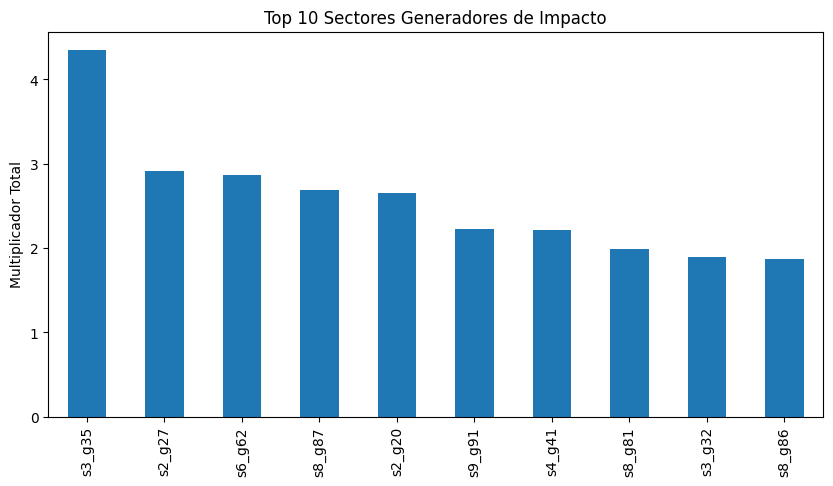

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
ranking_generadores.head(10).plot(kind='bar')
plt.title("Top 10 Sectores Generadores de Impacto")
plt.ylabel("Multiplicador Total")
plt.show()

# 4. Revisión del proyecto

In [36]:
col_sums = A_stable.sum(axis=0)

print("Columnas con suma >= 1:")
print(col_sums[col_sums >= 1])

Columnas con suma >= 1:
s2_g20    1.275658
s3_g35    2.038932
dtype: float64


In [37]:
# Checa si el índice coincide
print(L_df.index[:5])
print(sectores_nombres[:5])

Index(['s0_g1', 's0_g2', 's0_g3', 's0_g4', 's0_g5'], dtype='object')


NameError: name 'sectores_nombres' is not defined

In [38]:
f_test = np.zeros(len(L_df))
f_test[0] = 1_000_000  # shock en sector 0

x = L_df.values @ f_test

print("Sectores afectados:", np.count_nonzero(x))

Sectores afectados: 29


In [ ]:
L_df.to_excel("matriz.xlsx")

In [52]:
import json
import numpy as np
from IPython.display import HTML, display
from google.colab import files

# ============================================================
#  PASO 1: PREPARAR DATOS DESDE TUS VARIABLES
#  (todo viene de tu Colab, no cambies los nombres)
# ============================================================

# Nombres de sectores — tomados del orden de L_df (mismo que A_stable)
sectores_nombres =data["descripción sector_economico_2"].unique().tolist()
sectores_nombres.remove('Explotación de Sal')
# Coeficientes de empleo diag(L) — vector de 61 valores
coef_empleo = (Intensidad["I"] / 1e6).tolist()
# Inversa de Leontief (I-A)⁻¹ como lista de listas
leontief_inv = L_df.values.tolist()           # ← (I-A)⁻¹ de la fórmula

# ============================================================
#  PASO 2: CONSTRUCCIÓN DEL JSON
# ============================================================

sectores_json   = json.dumps(sectores_nombres)
coef_emp_json   = json.dumps(coef_empleo)
leontief_json   = json.dumps(leontief_inv)

# ============================================================
#  PASO 3: HTML + JS  —  cálculo: E = diag(L) · (I-A)⁻¹ · f
# ============================================================

html_code = f"""<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;500;600&display=swap');
  :root {{
    --bg:#f5f7fa; --surface:#ffffff; --border:#e2e6ed;
    --accent:#2d8cf0; --accent-light:#e8f3fe; --accent-dark:#1a6cc4;
    --text:#1a202c; --muted:#6b7a90; --input-bg:#f8fafc;
    --green:#16a34a; --green-bg:#f0fdf4; --red:#dc2626;
  }}
  *{{box-sizing:border-box;margin:0;padding:0;}}
  body{{background:var(--bg);color:var(--text);font-family:'IBM Plex Sans',sans-serif;font-size:14px;}}

  .top-bar{{background:var(--surface);border-bottom:1.5px solid var(--border);
    padding:14px 28px;display:flex;align-items:center;gap:16px;
    box-shadow:0 1px 4px rgba(0,0,0,0.05);}}
  .top-bar h1{{font-family:'IBM Plex Sans',sans-serif;font-size:1rem;font-weight:600;color:var(--text);}}
  .top-bar span{{font-size:0.72rem;color:var(--muted);}}
  .formula{{font-size:0.72rem;color:var(--accent);font-family:'IBM Plex Mono',monospace;
    margin-left:auto;background:var(--accent-light);padding:4px 12px;border-radius:6px;
    border:1px solid #c3dffe;}}

  .layout{{display:grid;grid-template-columns:1fr 300px;height:calc(100vh - 53px);}}
  .main{{overflow-y:auto;padding:20px 24px;}}

  /* Accordion */
  .sector-group{{margin-bottom:10px;border-radius:10px;overflow:hidden;
    background:var(--surface);box-shadow:0 1px 4px rgba(0,0,0,0.06);border:1px solid var(--border);}}
  .sector-header{{display:flex;align-items:center;padding:11px 16px;cursor:pointer;
    user-select:none;transition:background 0.15s;gap:10px;}}
  .sector-header:hover{{background:#f0f4fa;}}
  .sector-header.open{{background:var(--accent-light);border-bottom:1px solid #c3dffe;}}
  .sector-icon{{width:22px;height:22px;border-radius:50%;background:var(--accent-light);
    color:var(--accent);font-family:'IBM Plex Mono',monospace;font-size:0.62rem;font-weight:600;
    display:flex;align-items:center;justify-content:center;flex-shrink:0;
    border:1px solid #c3dffe;}}
  .sector-title{{font-size:0.78rem;font-weight:600;color:var(--text);flex:1;}}
  .sector-badge{{font-family:'IBM Plex Mono',monospace;font-size:0.65rem;
    color:var(--accent);background:var(--accent-light);border:1px solid #c3dffe;
    padding:2px 8px;border-radius:10px;white-space:nowrap;}}
  .sector-badge.has-value{{background:var(--accent);color:#fff;border-color:var(--accent-dark);}}
  .chevron{{width:14px;height:14px;color:var(--muted);transition:transform 0.2s;flex-shrink:0;}}
  .chevron.open{{transform:rotate(90deg);}}

  .sector-body{{display:none;}}
  .sector-body.open{{display:block;}}

  .sub-table{{width:100%;border-collapse:collapse;}}
  .sub-table thead th{{background:#f8fafc;font-family:'IBM Plex Mono',monospace;font-size:0.6rem;
    color:var(--muted);text-transform:uppercase;letter-spacing:0.07em;
    padding:7px 14px;text-align:left;border-bottom:1px solid var(--border);}}
  .sub-table thead th:nth-child(2),.sub-table thead th:nth-child(3){{text-align:right;}}
  .sub-table tbody tr{{border-bottom:1px solid #f0f2f6;transition:background 0.1s;}}
  .sub-table tbody tr:hover{{background:#f8fafc;}}
  .sub-table td{{padding:7px 14px;font-size:0.78rem;}}
  td.name{{color:var(--text);max-width:0;overflow:hidden;text-overflow:ellipsis;white-space:nowrap;width:100%;}}
  td.inv{{text-align:right;width:150px;}}
  td.emp{{text-align:right;width:170px;font-family:'IBM Plex Mono',monospace;font-size:0.75rem;}}
  td.emp.pos{{color:var(--green);font-weight:600;}}
  td.emp.neg{{color:var(--red);}}
  td.emp.zero{{color:var(--muted);}}

  input[type=number]{{
    background:var(--input-bg);border:1.5px solid var(--border);
    color:var(--text);font-family:'IBM Plex Mono',monospace;
    font-size:0.75rem;padding:5px 8px;border-radius:6px;
    width:120px;text-align:right;outline:none;transition:border-color 0.15s;
  }}
  input[type=number]:focus{{border-color:var(--accent);background:#fff;
    box-shadow:0 0 0 3px rgba(45,140,240,0.12);}}
  input[type=number]::-webkit-inner-spin-button{{opacity:0.4;}}

  /* Sidebar */
  .sidebar{{background:var(--surface);border-left:1.5px solid var(--border);
    overflow-y:auto;padding:20px 16px;display:flex;flex-direction:column;gap:12px;}}
  .sidebar-title{{font-size:0.65rem;font-weight:600;letter-spacing:0.08em;
    text-transform:uppercase;color:var(--muted);padding-bottom:4px;}}
  .kpi-card{{background:var(--surface);border:1.5px solid var(--border);
    border-radius:10px;padding:14px 16px;box-shadow:0 1px 4px rgba(0,0,0,0.05);}}
  .kpi-lbl{{font-family:'IBM Plex Mono',monospace;font-size:0.58rem;color:var(--muted);
    text-transform:uppercase;letter-spacing:0.08em;margin-bottom:5px;}}
  .kpi-val{{font-family:'IBM Plex Mono',monospace;font-size:1.7rem;font-weight:600;line-height:1;}}
  .kpi-val.green{{color:var(--green);}} .kpi-val.blue{{color:var(--accent);}}
  .kpi-sub{{font-size:0.65rem;color:var(--muted);margin-top:3px;}}
  .divider{{height:1px;background:var(--border);margin:4px 0;}}
  .top-list{{display:flex;flex-direction:column;gap:7px;}}
  .top-item{{display:flex;align-items:center;gap:7px;}}
  .top-item-name{{flex:1;color:var(--muted);overflow:hidden;text-overflow:ellipsis;
    white-space:nowrap;font-size:0.62rem;}}
  .top-item-bar-wrap{{width:50px;height:4px;background:var(--border);border-radius:3px;flex-shrink:0;}}
  .top-item-bar{{height:100%;background:var(--accent);border-radius:3px;transition:width 0.3s;}}
  .top-item-val{{font-family:'IBM Plex Mono',monospace;font-size:0.62rem;width:50px;
    text-align:right;color:var(--text);}}
  .reset-btn{{background:transparent;border:1.5px solid var(--border);color:var(--muted);
    font-family:'IBM Plex Mono',monospace;font-size:0.72rem;padding:9px;
    border-radius:8px;cursor:pointer;transition:all 0.15s;width:100%;}}
  .reset-btn:hover{{border-color:var(--red);color:var(--red);background:#fff5f5;}}
</style>
</head>
<body>
<div class="top-bar">
  <h1>Aproximación de un multiplicador de empleo</h1>
  <span>Ingresa inversión (MDP) por sector</span>
  <span class="formula">E = diag(L) · (I-A)⁻¹ · f</span>
</div>

<div class="layout">
  <div class="main" id="mainContent"></div>
  <div class="sidebar">
    <div class="sidebar-title">Panel de Control</div>
    <div class="kpi-card">
      <div class="kpi-lbl">Total Empleados Generados</div>
      <div class="kpi-val green" id="totalEmp">0</div>
      <div class="kpi-sub">Σ diag(L)·(I-A)⁻¹·f</div>
    </div>
    <div class="kpi-card">
      <div class="kpi-lbl">Total Inversión (MDP)</div>
      <div class="kpi-val blue" id="totalInv">0</div>
      <div class="kpi-sub">millones de pesos</div>
    </div>
    <div class="divider"></div>
    <div class="kpi-card">
      <div class="kpi-lbl">Top 8 por Empleados</div>
      <div class="top-list" id="topList"></div>
    </div>
    <button class="reset-btn" onclick="resetAll()">↺ Resetear todo</button>
  </div>
</div>

<script>
const SECTORES  = {sectores_json};
const COEF_EMP  = {coef_emp_json};
const L_INV     = {leontief_json};

const GRUPOS = [
  {{ id:0, label:"Sector Primario",       subs:[0,1,2,3,4] }},
  {{ id:1, label:"Minería",               subs:[5,6,7,8] }},
  {{ id:2, label:"Industria Manufactura I",subs:[9,10,11,12,13,14,15,16,17,18] }},
  {{ id:3, label:"Industria Manufactura II",subs:[19,20,21,22,23,24,25,26,27,28] }},
  {{ id:4, label:"Construcción",          subs:[29,30] }},
  {{ id:5, label:"Energía y Agua",        subs:[31,32] }},
  {{ id:6, label:"Comercio",              subs:[33,34,35,36,37,38,39,40,41] }},
  {{ id:7, label:"Transporte y Comunicaciones", subs:[42,43,44,45,46,47] }},
  {{ id:8, label:"Servicios Financieros y Profesionales", subs:[48,49,50,51,52,53,54,55,56] }},
  {{ id:9, label:"Servicios Sociales y Públicos", subs:[57,58,59,60] }}
];

const SECTOR_LABELS = [
  "0","0","0","0","0",
  "1","1","1","1",
  "2","2","2","2","2","2","2","2","2","2",
  "3","3","3","3","3","3","3","3","3","3",
  "4","4",
  "5","5",
  "6","6","6","6","6","6","6","6","6",
  "7","7","7","7","7","7",
  "8","8","8","8","8","8","8","8","8",
  "9","9","9","9"
];

const N = SECTORES.length;
const f = new Float64Array(N);
const empResult = new Float64Array(N);

function calcular() {{
  for (let i = 0; i < N; i++) {{
    let xi = 0;
    const row = L_INV[i];
    for (let j = 0; j < N; j++) xi += row[j] * f[j];
    empResult[i] = (COEF_EMP[i] * xi);
  }}
}}

function buildAccordion() {{
  const main = document.getElementById('mainContent');
  main.innerHTML = '';
  GRUPOS.forEach(grupo => {{
    const div = document.createElement('div');
    div.className = 'sector-group';
    div.id = 'group-' + grupo.id;

    const header = document.createElement('div');
    header.className = 'sector-header';
    header.innerHTML = `
      <div class="sector-icon">${{grupo.id}}</div>
      <span class="sector-title">${{grupo.label}}</span>
      <span class="sector-badge" id="badge-${{grupo.id}}">MDP 0</span>
      <svg class="chevron" id="chev-${{grupo.id}}" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2.5">
        <polyline points="9 18 15 12 9 6"></polyline>
      </svg>`;
    header.addEventListener('click', () => toggleGroup(grupo.id));

    const body = document.createElement('div');
    body.className = 'sector-body';
    body.id = 'body-' + grupo.id;

    const table = document.createElement('table');
    table.className = 'sub-table';
    table.innerHTML = `<thead><tr>
      <th>Sector</th><th>Inversión f (MDP)</th><th>Empleados Generados</th>
    </tr></thead>`;
    const tbody = document.createElement('tbody');

    grupo.subs.forEach(idx => {{
      const tr = document.createElement('tr');
      const e = empResult[idx];
      const cls = e > 0 ? 'pos' : e < 0 ? 'neg' : 'zero';
      tr.innerHTML = `
        <td class="name" title="${{SECTORES[idx]}}">${{SECTORES[idx]}}</td>
        <td class="inv">
          <input type="number" min="0" step="1" value="0"
            data-idx="${{idx}}" oninput="handleInput(this)">
        </td>
        <td class="emp ${{cls}}" id="emp-${{idx}}">${{Math.floor(e).toLocaleString('es-MX')}}</td>`;
      tbody.appendChild(tr);
    }});

    table.appendChild(tbody);
    body.appendChild(table);
    div.appendChild(header);
    div.appendChild(body);
    main.appendChild(div);
  }});
}}

function toggleGroup(id) {{
  const body = document.getElementById('body-' + id);
  const chev = document.getElementById('chev-' + id);
  const header = body.previousElementSibling;
  const isOpen = body.classList.contains('open');
  body.classList.toggle('open', !isOpen);
  chev.classList.toggle('open', !isOpen);
  header.classList.toggle('open', !isOpen);
}}

function updateTable() {{
  for (let i = 0; i < N; i++) {{
    const cell = document.getElementById('emp-' + i);
    if (!cell) continue;
    const e = empResult[i];
    cell.textContent = Math.floor(e).toLocaleString('es-MX');
    cell.className = 'emp ' + (e > 0 ? 'pos' : e < 0 ? 'neg' : 'zero');
  }}
}}

function updateBadges() {{
  GRUPOS.forEach(grupo => {{
    const total = grupo.subs.reduce((sum, idx) => sum + (f[idx] || 0), 0) / 1e6;
    const badge = document.getElementById('badge-' + grupo.id);
    if (!badge) return;
    if (total > 0) {{
      badge.textContent = 'MDP ' + total.toLocaleString('es-MX', {{maximumFractionDigits:1}});
      badge.classList.add('has-value');
    }} else {{
      badge.textContent = 'MDP 0';
      badge.classList.remove('has-value');
    }}
  }});
}}

function updateSidebar() {{
  const totEmp = Array.from(empResult).reduce((a, b) => a + b, 0);
  const totInv = Array.from(f).reduce((a, b) => a + b, 0) / 1e6;
  document.getElementById('totalEmp').textContent = Math.floor(totEmp).toLocaleString('es-MX');
  document.getElementById('totalInv').textContent = totInv.toLocaleString('es-MX', {{maximumFractionDigits:2}});

  const pairs = Array.from(empResult).map((e,i) => [i,e]).sort((a,b) => b[1]-a[1]).slice(0,8);
  const maxVal = pairs[0]?.[1] || 1;
  document.getElementById('topList').innerHTML = pairs.map(([i,e]) => `
    <div class="top-item">
      <span class="top-item-name" title="${{SECTORES[i]}}">${{SECTORES[i]}}</span>
      <div class="top-item-bar-wrap">
        <div class="top-item-bar" style="width:${{maxVal>0?Math.max(0,e/maxVal*100):0}}%"></div>
      </div>
      <span class="top-item-val">${{Math.floor(e).toLocaleString('es-MX')}}</span>
    </div>`).join('');
}}

function handleInput(inp) {{
  f[parseInt(inp.dataset.idx)] = (parseFloat(inp.value) || 0) * 1e6;
  calcular();
  updateTable();
  updateBadges();
  updateSidebar();
}}

function resetAll() {{
  f.fill(0);
  document.querySelectorAll('input[data-idx]').forEach(inp => inp.value = 0);
  calcular();
  updateTable();
  updateBadges();
  updateSidebar();
}}

calcular();
buildAccordion();
updateSidebar();
</script>
</body></html>"""

# ============================================================
#  PASO 4: DESCARGAR EL HTML
# ============================================================
nombre_archivo = "simulador_leontief.html"
with open(nombre_archivo, "w", encoding="utf-8") as fh:
    fh.write(html_code)

files.download(nombre_archivo)
print(f"✅ '{nombre_archivo}' descargado. Ábrelo en tu navegador.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 'simulador_leontief.html' descargado. Ábrelo en tu navegador.


In [43]:
print(Intensidad['I'])

0     1.641997
1     0.460710
2     0.440464
3     6.098039
4     6.098039
        ...   
56    0.951698
57    1.061654
58    0.142595
59    4.728019
60    4.728019
Name: I, Length: 61, dtype: float64


In [49]:
sectores_nombres.remove('Explotación de Sal')
print(f"Sectores encontrados: {len(sectores_nombres)}")
print(f"¿Hay NaN en la matriz?: {np.isnan(L_df.values).any()}")
print(f"¿Hay NaN en coeficientes?: {np.isnan(coef_empleo).any()}")

ValueError: list.remove(x): x not in list

In [51]:
#sectores_nombres.remove('Explotación de Sal')
sectores_nombres

['Agricultura',
 'Ganadería',
 'Silvicultura',
 'Pesca',
 'Caza',
 'Extracción y Beneficio de Carbón Mineral, Grafito y Minerales no Metálicos; excepto Sal',
 'Exploración y Extracción de Petróleo Crudo y Gas Natural',
 'Extracción y Beneficio de Minerales Metálicos',
 'Explotación de Sal',
 'Elaboración de Alimentos',
 'Elaboración de Bebidas',
 'Beneficio y/o Fabricación de Productos de Tabaco',
 'Industria Textil',
 'Confección de Prendas de Vestir y otros Artículos a base de Textiles y Materiales Diversos; excepto Calzado',
 'Fabricación de Calzado e Industria del Cuero',
 'Industria y Productos de Madera y Corcho; excepto Muebles',
 'Fabricación y/o Reparación de Muebles de Madera y sus Partes; excepto los de Metal y de Plástico Moldeado',
 'Industria del Papel',
 'Industrias Editorial, de Impresión y Conexas',
 'Industria Química',
 'Refinación del Petróleo y derivados del Carbón Mineral',
 'Fabricación de Productos de Hule y Plástico',
 'Fabricación de Productos de Minerales no 